<a href="https://colab.research.google.com/github/kaplunov-dmitrii/diffury/blob/main/2253_%D0%9A%D0%B0%D0%BF%D0%BB%D1%83%D0%BD%D0%BE%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_%D0%BF%D1%80%D0%BE_%D0%BF%D0%B5%D1%80%D0%B5%D0%BF%D1%80%D0%B0%D0%B2%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [118]:
x0, y0 = 10, 6
u, v = 2, 1

y = sp.symbols("y")
x = sp.Function("x")(y)

ode_inverted = sp.Eq(x.diff(y), (u * x - v * sp.sqrt(x**2 + y**2)) / (u * y))
ode_inverted

Eq(Derivative(x(y), y), (-sqrt(y**2 + x(y)**2) + 2*x(y))/(2*y))

In [119]:
sol_simb = sp.dsolve(ode_inverted, x)
sol_simb

Eq(x(y), y*sinh(C1 - log(sqrt(y))))

In [120]:
eq_ics = sp.Eq(sol_simb.rhs.subs(y, y0), x0)
C1_val = sp.solve(eq_ics, 'C1')[0]

solution = sp.Eq(x, sol_simb.rhs.subs('C1', C1_val))
solution

Eq(x(y), y*sinh(log(sqrt(y)) - log(-5*sqrt(6)/3 + 2*sqrt(51)/3)))

In [121]:
y_points = np.linspace(y0, 0.001, 500)
x_func = sp.lambdify(y, solution.rhs, 'numpy')
x_values = x_func(y_points)

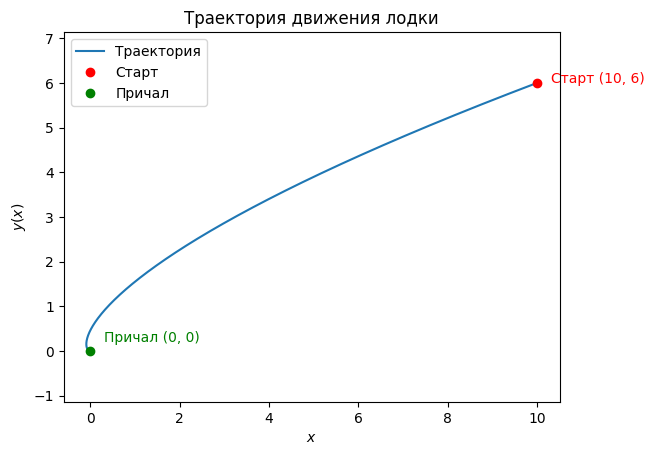

In [122]:
plt.plot(x_values, y_points, label='Траектория')

plt.plot(x0, y0, 'ro', label='Старт')
plt.text(x0 + 0.3, y0, 'Старт (10, 6)', fontsize=10, color='red')
plt.plot(0, 0, 'go', label='Причал')
plt.text(0.3, 0.2, 'Причал (0, 0)', fontsize=10, color='green')

plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.axis('equal')
plt.title('Траектория движения лодки')
plt.legend()
plt.show()